# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [1]:
# Установка необходимых библиотек
!pip install -q datasets tokenizers lightning torchmetrics matplotlib

import pandas as pd
import torch
import datasets
import lightning.pytorch as pl
import torch.nn as nn
import tokenizers
from tokenizers.trainers import BpeTrainer
from torch.utils.data import DataLoader
from datasets import Dataset, DatasetDict
from torch.nn.utils.rnn import pad_sequence
from typing import Dict
import torchmetrics
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Data

In [2]:
negative_file = 'negative.csv'
positive_file = 'positive.csv'

negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

sentiment = pd.concat([negative_df, positive_df], ignore_index=True)

# Оставляем только нужные столбцы
sentiment = sentiment[['ttext', 'ttype']].rename(columns={'ttext': 'text', 'ttype': 'type'})

# Нормализуем метки: 0 = негатив, 1 = позитив
sentiment['type'] = sentiment['type'].apply(lambda x: 0 if x < 0 else 1)

# Добавим нормализованный текст: lowercase, убираем спецсимволы и цифры
import re
sentiment['normalized_text'] = sentiment['text'].apply(lambda x: re.sub(r'[^a-zA-Zа-яА-ЯёЁ\s]', '', str(x).lower()))

# Токенизация: просто разбиваем по пробелам (можно заменить на кастомный токенизатор)
sentiment['tokens'] = sentiment['normalized_text'].apply(lambda x: x.split())

# Проверим результат
sentiment

,text,type,normalized_text,tokens
0,на работе был полный пиддес :| и так каждое за...,0,на работе был полный пиддес и так каждое закр...,"[на, работе, был, полный, пиддес, и, так, кажд..."
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0,коллеги сидят рубятся в urban terror а я изза ...,"[коллеги, сидят, рубятся, в, urban, terror, а,..."
2,@elina_4post как говорят обещаного три года жд...,0,elinapost как говорят обещаного три года ждут,"[elinapost, как, говорят, обещаного, три, года..."
3,"Желаю хорошего полёта и удачной посадки,я буду...",0,желаю хорошего полёта и удачной посадкия буду ...,"[желаю, хорошего, полёта, и, удачной, посадкия..."
4,"Обновил за каким-то лешим surf, теперь не рабо...",0,обновил за какимто лешим surf теперь не работа...,"[обновил, за, какимто, лешим, surf, теперь, не..."
...,...,...,...,...
226829,"Спала в родительском доме, на своей кровати......",1,спала в родительском доме на своей кровати про...,"[спала, в, родительском, доме, на, своей, кров..."
226830,RT @jebesilofyt: Эх... Мы немного решили сокра...,1,rt jebesilofyt эх мы немного решили сократить ...,"[rt, jebesilofyt, эх, мы, немного, решили, сок..."
226831,"Что происходит со мной, когда в эфире #proacti...",1,что происходит со мной когда в эфире proactive...,"[что, происходит, со, мной, когда, в, эфире, p..."
226832,"""Любимая,я подарю тебе эту звезду..."" Имя како...",1,любимаяя подарю тебе эту звезду имя какой звез...,"[любимаяя, подарю, тебе, эту, звезду, имя, как..."


In [3]:
sentiment.to_csv('sentiment_preprocessed.csv', index=False)

In [4]:
df = pd.read_csv("/content/sentiment_preprocessed.csv")
df = df[['normalized_text', 'type']].rename(columns={'normalized_text': 'text', 'type': 'label'})
df['label'] = df['label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df),
})

# Model

In [5]:
class MyDataModule(pl.LightningDataModule):
    def __init__(self, dataset, vocab_size=5000, max_length=256, bs=64):
        super().__init__()
        self.raw_dataset = dataset
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.bs = bs

    def setup(self, stage=None):
        self.tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[UNK]"))
        trainer = BpeTrainer(vocab_size=self.vocab_size, special_tokens=["[UNK]", "[PAD]"])
        self.tokenizer.train_from_iterator(self.raw_dataset['train']['text'], trainer=trainer)
        self.tokenizer.enable_padding(pad_token="[PAD]")
        self.tokenizer.enable_truncation(max_length=self.max_length)

        def encode(batch):
            out = self.tokenizer.encode(batch["text"])
            return {"input_ids": out.ids, "label": batch["label"]}

        self.dataset = self.raw_dataset.map(encode)

    def collate_fn(self, batch):
        input_ids = [torch.tensor(item['input_ids']) for item in batch]
        input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
        labels = torch.tensor([item['label'] for item in batch])
        return {"input_ids": input_ids, "labels": labels}

    def train_dataloader(self):
        return DataLoader(self.dataset['train'], batch_size=self.bs, shuffle=True, collate_fn=self.collate_fn)

    def val_dataloader(self):
        return DataLoader(self.dataset['validation'], batch_size=self.bs, collate_fn=self.collate_fn)

    def test_dataloader(self):
        return DataLoader(self.dataset['test'], batch_size=self.bs, collate_fn=self.collate_fn)


In [6]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size=128, hidden_size=128, output_size=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=0)
        self.rnn = nn.GRU(embd_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.loss_fn = nn.CrossEntropyLoss()

        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)

    def forward(self, x):
        x = self.embedding(x)
        _, h = self.rnn(x)
        return self.fc(h.squeeze(0))

    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['labels']
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.train_f1(logits, y)
        self.log("train_f1", self.train_f1, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['labels']
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.val_f1(logits, y)
        self.log("val_f1", self.val_f1, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['labels']
        logits = self(x)
        self.test_f1(logits, y)
        self.log("test_f1", self.test_f1, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


# Trainer

In [7]:
vocab_sizes = [500, 1000, 3000, 5000, 10000]
f1_scores = []

for vocab_size in vocab_sizes:
    print(f"\nTraining with vocab_size = {vocab_size}")
    dm = MyDataModule(dataset, vocab_size=vocab_size)
    dm.setup()

    model = RNNModel(vocab_size=vocab_size)
    trainer = pl.Trainer(max_epochs=3, logger=False, enable_checkpointing=False)
    trainer.fit(model, datamodule=dm)
    test_result = trainer.test(model, datamodule=dm, verbose=False)
    f1_scores.append(test_result[0]['test_f1'])



Training with vocab_size = 500


Map:   0%|          | 0/181467 [00:00<?, ? examples/s]

Map:   0%|          | 0/22683 [00:00<?, ? examples/s]

Map:   0%|          | 0/22684 [00:00<?, ? examples/s]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


...

Map:   0%|          | 0/181467 [00:00<?, ? examples/s]

Map:   0%|          | 0/22683 [00:00<?, ? examples/s]

Map:   0%|          | 0/22684 [00:00<?, ? examples/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

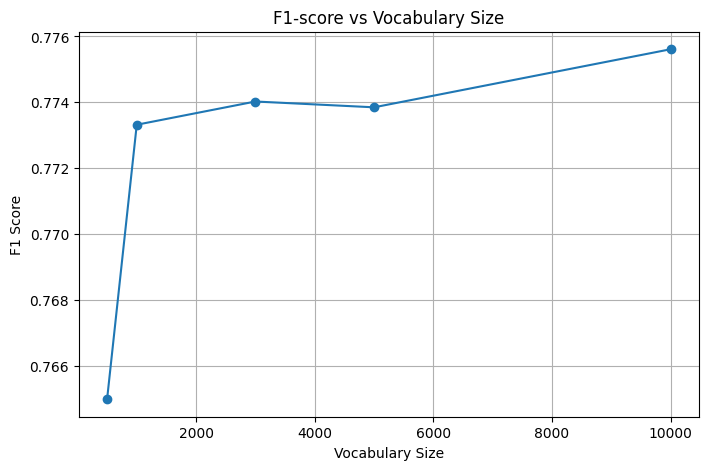

In [8]:
plt.figure(figsize=(8,5))
plt.plot(vocab_sizes, f1_scores, marker='o')
plt.title("F1-score vs Vocabulary Size")
plt.xlabel("Vocabulary Size")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()